In [ ]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
filename = "Crop Suitability Prediction_06022024"
df = pd.read_csv(filename)
df.dropna(axis=1)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [66]:
string_columns = df.select_dtypes(include=["object"]).columns
unique_data = set([i[0] for i in string_columns.values])

for column in string_columns:
    print(f"{column} - {len(set(df[column]))} Unique Items")
    for i in set(df[column]):
        print(i)
    print("\n")

label - 22 Unique Items
papaya
apple
blackgram
coconut
muskmelon
mango
pomegranate
orange
chickpea
grapes
mungbean
jute
rice
banana
kidneybeans
watermelon
pigeonpeas
mothbeans
cotton
lentil
maize
coffee




In [67]:
def encode():
    string_columns = df.select_dtypes(include=["object"]).columns
    encoders = {}
    for column in string_columns:
        enc = LabelEncoder()
        df[column] = enc.fit_transform(df[column])
        encoders[column] = enc
    return encoders

encoders = encode()

<Axes: >

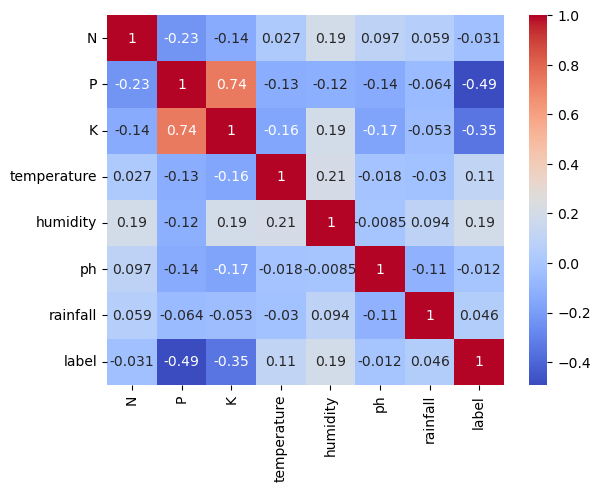

In [68]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")